In [1]:
import catalogue_analysis as ca
import redshift_weights as rw
import numpy as np
from astropy.table import join,Table,Column,vstack,setdiff
from astropy.io import fits
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
dat=Table.read('sdata/BGS_Y3_15April2026.fits')
print('number of unique Target IDs:', np.unique(dat['TARGETID']).size)

number of unique Target IDs: 7874903


In [3]:
dat.info('stats')

<Table length=7874903>
       name            mean         std         min          max    
------------------ ------------ ----------- ------------ -----------
          TARGETID  3.96297e+16 2.48551e+12  3.96273e+16 3.96374e+16
            TILEID      23114.2     1881.87        20000       27852
                 Z     0.213345    0.104259   0.00200098     0.59999
             NTILE      2.43434    0.916934            1           5
                RA      183.078     91.2515  0.000108207         360
               DEC      21.9899     23.0655     -19.5559     79.2584
           PHOTSYS           --          --           --          --
  FRAC_TLOBS_TILES     0.984397    0.027012     0.333333           1
      WEIGHT_ZFAIL      1.00127  0.00523178            1     1.19871
        BITWEIGHTS -5.27255e+14 3.02575e+18 -9.22337e+18 9.22337e+18
          PROB_OBS       0.8551    0.209397            0           1
            WEIGHT      1.30432    0.790294            1     74.1026
       WEIG

In [4]:
# John Moustakas's Value Added Catalog (VAC) is divided into 12 files based on an nsides=1 Healpix pixelisation.
# Here we read all 12, keep only the TARGETID and SHAPE information and concaternate into a single table.
for i in range(0,12):
    hp=f"{i:02d}"
    vachpfile='/global/cfs/cdirs/desi/vac/dr2/lsdr9-photometry/loa/v1.0/observed-targets/targetphot-nside1-hp'+hp+'-main-bright-loa.fits'
    print(vachpfile)
    vac=Table.read(vachpfile)
    vac_small=vac[['TARGETID', 'SHAPE_E1', 'SHAPE_E2', 'SHAPE_R']].copy()
    vac_small.meta.clear() # remove meta data to avoid conflict warning when tables are merged
    if (i==0):
        vacshape=vac_small
    else:    
        vacshape=vstack([vacshape,vac_small])
    del vac,vac_small

vacshape.info('stats')

/global/cfs/cdirs/desi/vac/dr2/lsdr9-photometry/loa/v1.0/observed-targets/targetphot-nside1-hp00-main-bright-loa.fits
/global/cfs/cdirs/desi/vac/dr2/lsdr9-photometry/loa/v1.0/observed-targets/targetphot-nside1-hp01-main-bright-loa.fits
/global/cfs/cdirs/desi/vac/dr2/lsdr9-photometry/loa/v1.0/observed-targets/targetphot-nside1-hp02-main-bright-loa.fits
/global/cfs/cdirs/desi/vac/dr2/lsdr9-photometry/loa/v1.0/observed-targets/targetphot-nside1-hp03-main-bright-loa.fits
/global/cfs/cdirs/desi/vac/dr2/lsdr9-photometry/loa/v1.0/observed-targets/targetphot-nside1-hp04-main-bright-loa.fits
/global/cfs/cdirs/desi/vac/dr2/lsdr9-photometry/loa/v1.0/observed-targets/targetphot-nside1-hp05-main-bright-loa.fits
/global/cfs/cdirs/desi/vac/dr2/lsdr9-photometry/loa/v1.0/observed-targets/targetphot-nside1-hp06-main-bright-loa.fits
/global/cfs/cdirs/desi/vac/dr2/lsdr9-photometry/loa/v1.0/observed-targets/targetphot-nside1-hp07-main-bright-loa.fits
/global/cfs/cdirs/desi/vac/dr2/lsdr9-photometry/loa/v1.0

In [5]:
# Match objects in dat that are in vacshape and copy across their shape parameters
len_before=len(dat)
vacshape.meta.clear() # remove meta data to avoid conflict warning when tables are merged
dat = join(dat, vacshape['TARGETID','SHAPE_R','SHAPE_E1','SHAPE_E2'], keys='TARGETID', join_type='left')
len_after=len(dat)
if (len_before!=len_after): print('WARNING: dat table changed length when matching from ',len_before,' to ',len_after)
dat.info('stats')

#If the table grows then this should only happen if there are repeated TARGETID in the first table.  I need to check!!!
print('number of unique Target IDs:', np.unique(dat['TARGETID']).size)

<Table length=8266875>
       name            mean         std         min          max    
------------------ ------------ ----------- ------------ -----------
          TARGETID  3.96297e+16 2.48811e+12  3.96273e+16 3.96374e+16
            TILEID        23110     1867.25        20000       27852
                 Z     0.213436     0.10435   0.00200098     0.59999
             NTILE      2.45014     0.91914            1           5
                RA      182.217     91.2853  0.000108207         360
               DEC      21.9945     23.1046     -19.5559     79.2584
           PHOTSYS           --          --           --          --
  FRAC_TLOBS_TILES     0.984671   0.0268293     0.333333           1
      WEIGHT_ZFAIL      1.00128  0.00524559            1     1.19871
        BITWEIGHTS -3.82317e+14 2.98381e+18 -9.22337e+18 9.22337e+18
          PROB_OBS     0.859097    0.207854            0           1
            WEIGHT      1.29658    0.780276            1     74.1026
       WEIG

In [6]:
# Convert Astropy table to Pandas DataFrame
names = [name for name in dat.colnames if len(dat[name].shape) <= 1]
df=dat[names].to_pandas()


# Drop duplicates based on TARGETID
dat_unique = df.drop_duplicates(subset='TARGETID')

unique_table = Table.from_pandas(dat_unique)
print('number of unique Target IDs:', np.unique(unique_table['TARGETID']).size)

number of unique Target IDs: 7874903


In [7]:
# Replace the dat table with the version with only unique rows
del dat 
dat=unique_table

In [8]:
print('SHAPE_R: Mean difference:',np.mean(dat['SHAPE_R_1']-dat['SHAPE_R_2']))
print('SHAPE_R: STD:',np.std(dat['SHAPE_R_1']-dat['SHAPE_R_2']))

SHAPE_R: Mean difference: 0.0
SHAPE_R: STD: 0.0


/tmp/ipykernel_1771797/3339984420.py:5: RuntimeWarning: divide by zero encountered in log10
  SB=dat['rmag']+2.5*np.log10(2.0*np.pi*(dat['SHAPE_R_1']**2)*bovera)


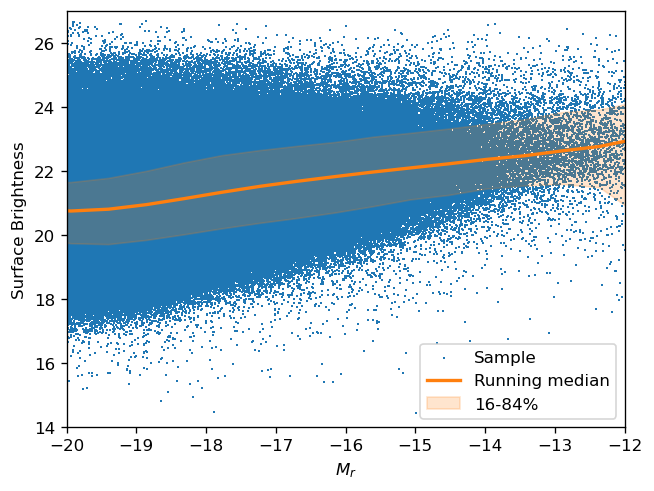

In [15]:
#Compute mean interior surface brightness at the half light radius (initially assuming circular) and plot against absolute magnitude

epsilon= np.sqrt( dat['SHAPE_E1_1']**2 +  dat['SHAPE_E2_1']**2 )
bovera= (1-epsilon)/(1+epsilon) # minor over major axis ratio
SB=dat['rmag']+2.5*np.log10(2.0*np.pi*(dat['SHAPE_R_1']**2)*bovera)
#plt.scatter(dat['ABSMAG_RP1'],SB,marker=',',lw=0,s=1.0,label='First',alpha=0.1)


# 2) Define bins along M_r (choose width or number of bins)
xmin, xmax = -24, -11
nbins = 24                      # e.g., 24 bins => ~0.5 mag each
edges = np.linspace(xmin, xmax, nbins+1)
centers = 0.5*(edges[:-1] + edges[1:])

# 3) Compute quantiles per bin
def binned_quantiles(x, y, edges, qs=(0.5, 0.16, 0.84)):
    # qs are quantiles (0.5=median, 0.16/0.84 ~ ±1σ for normal)
    qvals = np.full((len(qs), len(edges)-1), np.nan)
    counts = np.zeros(len(edges)-1, dtype=int)
    for i in range(len(edges)-1):
        m = (x >= edges[i]) & (x < edges[i+1])
        counts[i] = m.sum()
        if counts[i] > 0:
            qvals[:, i] = np.quantile(y[m], qs)
    return qvals, counts

qs = (0.5, 0.16, 0.84)  # median and ~68% envelope
qvals, counts = binned_quantiles(dat['ABSMAG_RP1'], SB, edges, qs=qs)

median = qvals[0]
p16 = qvals[1]
p84 = qvals[2]

# 4) Plot: scatter + median + percentile band
fig, ax = plt.subplots(figsize=(6,4.5), dpi=120)
ax.scatter(dat['ABSMAG_RP1'], SB, marker=',', lw=0, s=1.0, alpha=1.0, label='Sample')

ax.plot(centers, median, color='C1', lw=2, label='Running median')
ax.fill_between(centers, p16, p84, color='C1', alpha=0.2, label='16-84%')


plt.xlim(-20,-12)
plt.ylim(14,27)
plt.xlabel('$M_r$')
plt.ylabel('Surface Brightness')
plt.legend(loc='lower right')
plt.show()


/tmp/ipykernel_1771797/3339984420.py:5: RuntimeWarning: divide by zero encountered in log10
  SB=dat['rmag']+2.5*np.log10(2.0*np.pi*(dat['SHAPE_R_1']**2)*bovera)


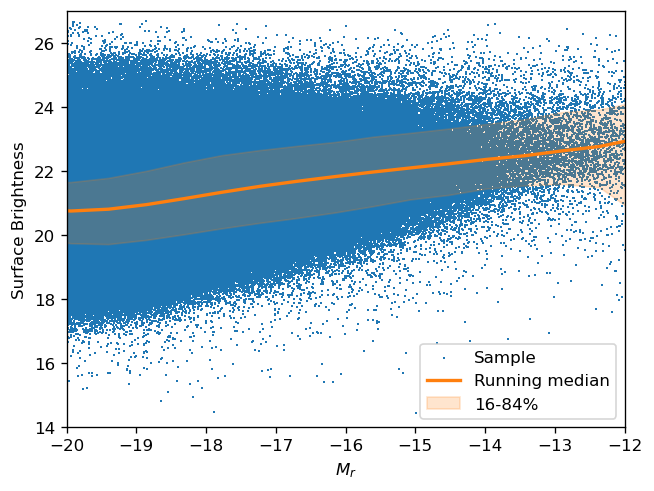

In [15]:
#Compute mean interior surface brightness at the half light radius (initially assuming circular) and plot against absolute magnitude

epsilon= np.sqrt( dat['SHAPE_E1_1']**2 +  dat['SHAPE_E2_1']**2 )
bovera= (1-epsilon)/(1+epsilon) # minor over major axis ratio
SB=dat['rmag']+2.5*np.log10(2.0*np.pi*(dat['SHAPE_R_1']**2)*bovera)
#plt.scatter(dat['ABSMAG_RP1'],SB,marker=',',lw=0,s=1.0,label='First',alpha=0.1)


# 2) Define bins along M_r (choose width or number of bins)
xmin, xmax = -24, -11
nbins = 24                      # e.g., 24 bins => ~0.5 mag each
edges = np.linspace(xmin, xmax, nbins+1)
centers = 0.5*(edges[:-1] + edges[1:])

# 3) Compute quantiles per bin
def binned_quantiles(x, y, edges, qs=(0.5, 0.16, 0.84)):
    # qs are quantiles (0.5=median, 0.16/0.84 ~ ±1σ for normal)
    qvals = np.full((len(qs), len(edges)-1), np.nan)
    counts = np.zeros(len(edges)-1, dtype=int)
    for i in range(len(edges)-1):
        m = (x >= edges[i]) & (x < edges[i+1])
        counts[i] = m.sum()
        if counts[i] > 0:
            qvals[:, i] = np.quantile(y[m], qs)
    return qvals, counts

qs = (0.5, 0.16, 0.84)  # median and ~68% envelope
qvals, counts = binned_quantiles(dat['ABSMAG_RP1'], SB, edges, qs=qs)

median = qvals[0]
p16 = qvals[1]
p84 = qvals[2]

# 4) Plot: scatter + median + percentile band
fig, ax = plt.subplots(figsize=(6,4.5), dpi=120)
ax.scatter(dat['ABSMAG_RP1'], SB, marker=',', lw=0, s=1.0, alpha=1.0, label='Sample')

ax.plot(centers, median, color='C1', lw=2, label='Running median')
ax.fill_between(centers, p16, p84, color='C1', alpha=0.2, label='16-84%')


plt.xlim(-20,-12)
plt.ylim(14,27)
plt.xlabel('$M_r$')
plt.ylabel('Surface Brightness')
plt.legend(loc='lower right')
plt.show()


In [ ]:
mask=(np.abs(dat['ABSMAG_RP1']+20.0)<0.5) & ( SB>10)
SB_filtered = SB[mask]

# Plot histogram of filtered y values
#plt.hist(SB_filtered, bins='auto', edgecolor='black')

bins = np.arange(15, 27, 0.1) 
counts1, bin_edges = np.histogram(SB_filtered, bins=bins, density=True)
bin_cen=(bin_edges[1:]+bin_edges[:-1])/2.0
plt.plot(bin_cen,counts1,marker=',', linestyle='-', label='$M_r=20$')

mask=(np.abs(dat['ABSMAG_RP1']+13.0)<0.5) & ( SB>10)
SB_filtered = SB[mask]
counts2, bin_edges = np.histogram(SB_filtered, bins=bins, density=True)
plt.plot(bin_cen,counts2,marker=',', linestyle='-', label='$M_r=13$')

plt.plot(bin_cen+1.8,counts1,marker=',', linestyle='-', label='$M_r=20 shifted$')
plt.ylim([0,0.5])
plt.xlabel('Surface Brightness')
plt.ylabel('Frequency')
plt.legend()
plt.show()


In [ ]:

# 2) Define bins along M_r (choose width or number of bins)
xmin, xmax = 10,19.5
nbins = 24                      # e.g., 24 bins => ~0.5 mag each
edges = np.linspace(xmin, xmax, nbins+1)
centers = 0.5*(edges[:-1] + edges[1:])

# 3) Compute quantiles per bin
def binned_quantiles(x, y, edges, qs=(0.5, 0.16, 0.84)):
    # qs are quantiles (0.5=median, 0.16/0.84 ~ ±1σ for normal)
    qvals = np.full((len(qs), len(edges)-1), np.nan)
    counts = np.zeros(len(edges)-1, dtype=int)
    for i in range(len(edges)-1):
        m = (x >= edges[i]) & (x < edges[i+1])
        counts[i] = m.sum()
        if counts[i] > 0:
            qvals[:, i] = np.quantile(y[m], qs)
    return qvals, counts

qs = (0.5, 0.05, 0.95)  # median and ~68% envelope
qvals, counts = binned_quantiles(dat['rmag'], SB, edges, qs=qs)

median = qvals[0]
p16 = qvals[1]
p84 = qvals[2]

# 4) Plot: scatter + median + percentile band
fig, ax = plt.subplots(figsize=(6,4.5), dpi=120)
ax.scatter(dat['rmag'], SB, marker=',', lw=0, s=1.0, alpha=1.0, label='Sample')

ax.plot(centers, median, color='C1', lw=2, label='Running median')
ax.fill_between(centers, p16, p84, color='C1', alpha=0.2, label='5-95%')


plt.xlim(10.0,19.5)
plt.xlabel('$rmag$')
plt.ylabel('Surface Brightness')
plt.legend(loc='lower right')
plt.show()


In [ ]:
mask=( SB>10)
SB_filtered = SB[mask]

# Plot histogram of filtered y values
#plt.hist(SB_filtered, bins='auto', edgecolor='black')

bins = np.arange(15, 27, 0.1) 
counts1, bin_edges = np.histogram(SB_filtered, bins=bins, density=True)
bin_cen=(bin_edges[1:]+bin_edges[:-1])/2.0
plt.plot(bin_cen,counts1,marker=',', linestyle='-', label='All')


plt.ylim([0,0.5])
plt.xlabel('Surface Brightness')
plt.ylabel('Frequency')
plt.legend()
plt.show()
